# Breast cancer molecular subtype classification
**Zirui Chen · NTU Biomedical Data Science coursework portfolio**

This analysis explores TCGA-BRCA expression profiles and classifies Luminal A versus
Luminal B using a random forest. It compares a baseline with an MCC-tuned model,
then applies Boruta to the principal components and examines their gene loadings.

The course data contain **26,991 normalized gene-expression measurements across
1,190 samples**, including breast tumors and normal tissue. Source: *Homework
Assignment 5*, slides 1–3. See [data/README.md](../data/README.md) for the clinical columns.

This edition reorganizes the original code and retains its saved results. No models
were rerun. An important qualification is that variance filtering, scaling and PCA
were fitted before the train/test split in the original workflow; the reported
scores therefore are exploratory rather than leakage-free generalization estimates.


In [ ]:
from pathlib import Path
import os
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc, make_scorer, matthews_corrcoef

# Open from the repository root or its notebooks/ directory.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "raw"
RESULT_DIR = ROOT / "results" / "luminal_subtype" / "rerun"


## 1. Load TCGA-BRCA data and filter low-variance genes

The original lower-quartile variance cutoff was **0.451042**, retaining **20,243 genes**. This filtering step was fitted on the full cohort and is preserved as part of the original workflow.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns

print("Reading gene expression data...")
expression_data = pd.read_csv(DATA_DIR / "HW5data.csv", index_col=0)
print(f"Gene Expression Data Shape: {expression_data.shape}")
print(f"Number of genes: {expression_data.shape[0]}, Number of sampless: {expression_data.shape[1]}")
print("\nReading clinical data...")
clinical_data = pd.read_csv(DATA_DIR / "HW5clinical.csv", encoding="utf-8-sig")
print(f"Clinical Data Shape: {clinical_data.shape}")

print("\nGene expression data information:")
print(expression_data.info())
print(f"\nNumber of Missing Values: {expression_data.isnull().sum().sum()}")

print("\nTransposed gene expression data...")
expression_data_transposed = expression_data.T
print(f"Transposed shape: {expression_data_transposed.shape}")

print("\nCalculate the variance for each gene...")
gene_variances = expression_data.var(axis=1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(gene_variances, bins=50, edgecolor='black', alpha=0.7)
plt.title('Gene expression variance distribution')
plt.xlabel('Variance')
plt.ylabel('Number of genes')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(gene_variances)
plt.title('Gene expression variance')
plt.ylabel('Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nScreening genes using the variance threshold method...")
# Retain genes above the original lower-quartile variance cutoff.
variance_threshold = np.percentile(gene_variances, 25)
print(f"Selected variance threshold: {variance_threshold:.6f}")

high_var_indices = gene_variances > variance_threshold
high_var_genes = expression_data[high_var_indices]
print(f"Number of genes after screening: {high_var_genes.shape[0]}")
print(f"Remain {high_var_genes.shape[0]/expression_data.shape[0]*100:.2f}% genes")


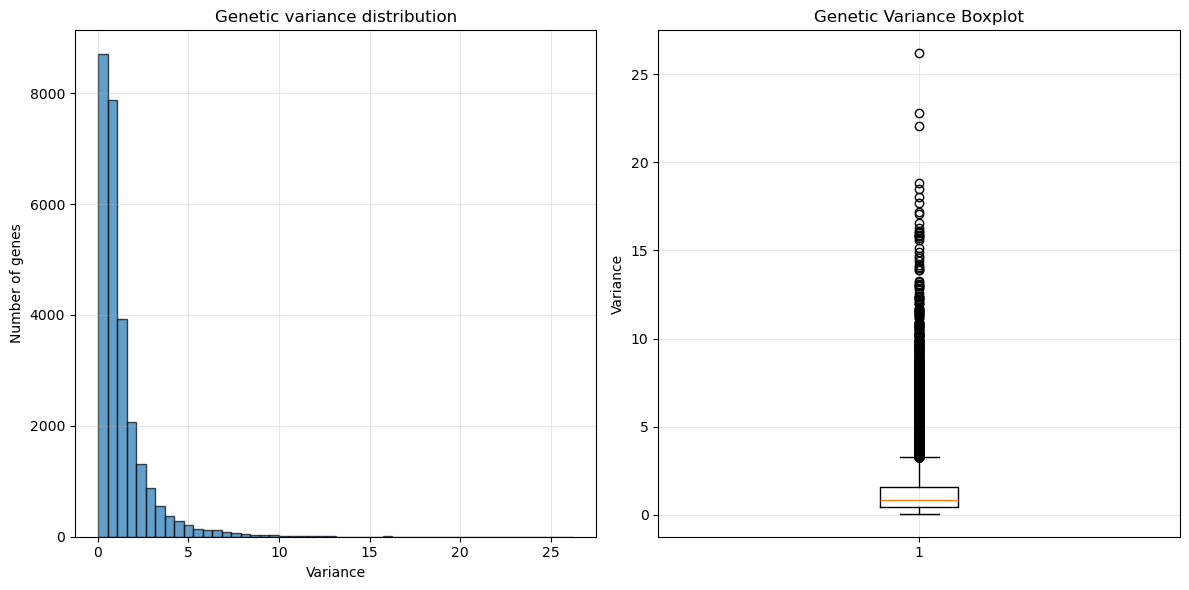

*Figure retained from the original homework run; not regenerated.*


## 2. Explore the supplied PAM50 groups with PCA

The clinical field is named `pam50`. Its values include `Normal`, which the code displays as `Normal-like`, and `Healthy`, the course label for normal tissue. Saved counts: LumA 560, LumB 209, Her2 82, Basal 188, Normal-like 39 and Healthy 112. All 1,190 barcodes matched directly in the original run.


In [ ]:
print("\nPrepare data for PCA...")

expression_pca_data = high_var_genes.T  
print(f"PCA input shape: {expression_pca_data.shape}")

print("\nExtracting subtype information from clinical data...")

if 'pam50' in clinical_data.columns:
    print("PAM50 labels found")

    if 'barcode' in clinical_data.columns:
        sample_id_col = 'barcode'
    else:
        possible_id_cols = ['sample', 'sample_id', 'id', 'patient']
        sample_id_col = None
        for col in possible_id_cols:
            if col in clinical_data.columns:
                sample_id_col = col
                break
        
        if sample_id_col is None:

            sample_id_col = clinical_data.columns[0]
    
    print(f"Using '{sample_id_col}' as sample ID")

    subtype_dict = {}
    for _, row in clinical_data.iterrows():
        sample_id = row[sample_id_col]
        subtype = row['pam50']

        if pd.isna(subtype):
            continue
        
        subtype = str(subtype).strip()
        if subtype.lower() == 'luma':
            subtype = 'LumA'
        elif subtype.lower() == 'lumb':
            subtype = 'LumB'
        elif subtype.lower() == 'her2':
            subtype = 'Her2'
        elif subtype.lower() in ['basal', 'basal-like']:
            subtype = 'Basal'
        elif subtype.lower() in ['normal', 'normal-like']:
            subtype = 'Normal-like'
        elif subtype.lower() in ['healthy', 'normal tissue']:
            subtype = 'Healthy'
        
        subtype_dict[sample_id] = subtype
    
    print(f"Extracted {len(subtype_dict)} samples information")
else:
    print("Required column pam50 was not found")
    raise ValueError("Check the input cohort and required clinical columns.")

print("\nMatching expression data samples with subtype information...")

expression_sample_ids = expression_pca_data.index.tolist()

subtype_labels = []
matched_samples = []
unmatched_samples = []

for sample_id in expression_sample_ids:
    matched = False

    if sample_id in subtype_dict:
        subtype_labels.append(subtype_dict[sample_id])
        matched_samples.append(sample_id)
        matched = True
    else:

        for clinical_id, subtype in subtype_dict.items():
            if sample_id in clinical_id or clinical_id in sample_id:
                subtype_labels.append(subtype)
                matched_samples.append(sample_id)
                matched = True
                break
    
    if not matched:
        subtype_labels.append('Unknown')
        unmatched_samples.append(sample_id)


In [ ]:
print(f"Successful match {len(matched_samples)} samples")
print(f"Unsuccessful match {len(unmatched_samples)} samples")

if len(unmatched_samples) > 0:
    print("The first 5 unmatched samples:")
    for sample in unmatched_samples[:5]:
        print(f"  {sample}")

print("\nSubtype distribution:")
from collections import Counter
subtype_counts = Counter(subtype_labels)
for subtype, count in subtype_counts.items():
    print(f"  {subtype}: {count}")

print("\nData Standardization...")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
expression_scaled = scaler.fit_transform(expression_pca_data)

print("\nRunning PCA...")
from sklearn.decomposition import PCA

pca = PCA(n_components=min(50, expression_scaled.shape[1]))
pca_result = pca.fit_transform(expression_scaled)

print(f"PCA completed, yielding {pca_result.shape[1]} PCA")
print(f"Proportion of variance explained by the top 10 principal components:")
for i, ratio in enumerate(pca.explained_variance_ratio_[:10], 1):
    print(f"  PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10])
plt.xlabel('Principal component')
plt.ylabel('Proportion of variance explained')
plt.title('Proportion of variance explained by the top 10 principal components')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% variance')
plt.axhline(y=0.90, color='g', linestyle='--', alpha=0.5, label='90% variance')
plt.axhline(y=0.80, color='y', linestyle='--', alpha=0.5, label='80% variance')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative variance explained')
plt.title('Cumulative variance explained')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\nDefine Subtype Color Mapping...")

subtype_list = ['Healthy', 'LumA', 'Normal-like', 'LumB', 'Her2', 'Basal', 'Unknown']

subtype_colors = {
    'Healthy': 'green',      
    'LumA': 'blue',           
    'Normal-like': 'cyan',   
    'LumB': 'purple',         
    'Her2': 'orange',         
    'Basal': 'red',          
    'Unknown': 'gray'        
}

sample_colors = [subtype_colors.get(subtype, 'gray') for subtype in subtype_labels]

legend_elements = []
for subtype in ['Healthy', 'LumA', 'Normal-like', 'LumB', 'Her2', 'Basal']:
    count = subtype_counts.get(subtype, 0)
    if count > 0:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=subtype_colors[subtype],
                                          markersize=10, label=f'{subtype} (n={count})'))


In [ ]:
print("\n3D Scatter Plot...")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2],
                    c=sample_colors, alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)')
ax.set_title('3D PCA')

ax.legend(handles=legend_elements, loc='upper left', fontsize=9, 
          bbox_to_anchor=(1.05, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()

print("\nFaceted diagram...")

pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'PC3': pca_result[:, 2],
    'Subtype': subtype_labels,
    'Sample': expression_pca_data.index
})

known_subtypes = [st for st in subtype_list if st != 'Unknown']
pca_df_known = pca_df[pca_df['Subtype'].isin(known_subtypes)]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, subtype in enumerate(known_subtypes):
    if i >= len(axes):
        break
        
    ax = axes[i]
    
    subtype_data = pca_df_known[pca_df_known['Subtype'] == subtype]
    
    other_data = pca_df_known[pca_df_known['Subtype'] != subtype]
    
    ax.scatter(other_data['PC1'], other_data['PC2'],
               color='lightgray', alpha=0.2, s=15, label='Other subtypes')
    
    ax.scatter(subtype_data['PC1'], subtype_data['PC2'],
               color=subtype_colors[subtype], alpha=0.7, s=30, label=subtype)
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{subtype} (n={len(subtype_data)})')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

for i in range(len(known_subtypes), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution of molecular subtypes in PCA space (PC1 vs PC2)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\nCalculate the degree of separation between subtypes:")

subtype_centers = {}
for subtype in known_subtypes:
    subtype_indices = pca_df_known['Subtype'] == subtype
    if sum(subtype_indices) > 0:
        center_pc1 = pca_df_known.loc[subtype_indices, 'PC1'].mean()
        center_pc2 = pca_df_known.loc[subtype_indices, 'PC2'].mean()
        subtype_centers[subtype] = (center_pc1, center_pc2)
        print(f"  {subtype}: PC1={center_pc1:.3f}, PC2={center_pc2:.3f}")


In [ ]:
print("\nSubtype centroids...")

plt.figure(figsize=(10, 8))

plt.scatter(pca_df_known['PC1'], pca_df_known['PC2'],
           color='lightgray', alpha=0.2, s=10, label='All samples')

for subtype, (center_pc1, center_pc2) in subtype_centers.items():
    plt.scatter(center_pc1, center_pc2, 
               color=subtype_colors[subtype], s=200, 
               edgecolor='black', linewidth=2, 
               marker='s', label=f'{subtype} center')
    
    plt.annotate(subtype, (center_pc1, center_pc2),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, fontweight='bold',
                color=subtype_colors[subtype])

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('The central positions of different molecular subtypes in PCA space')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


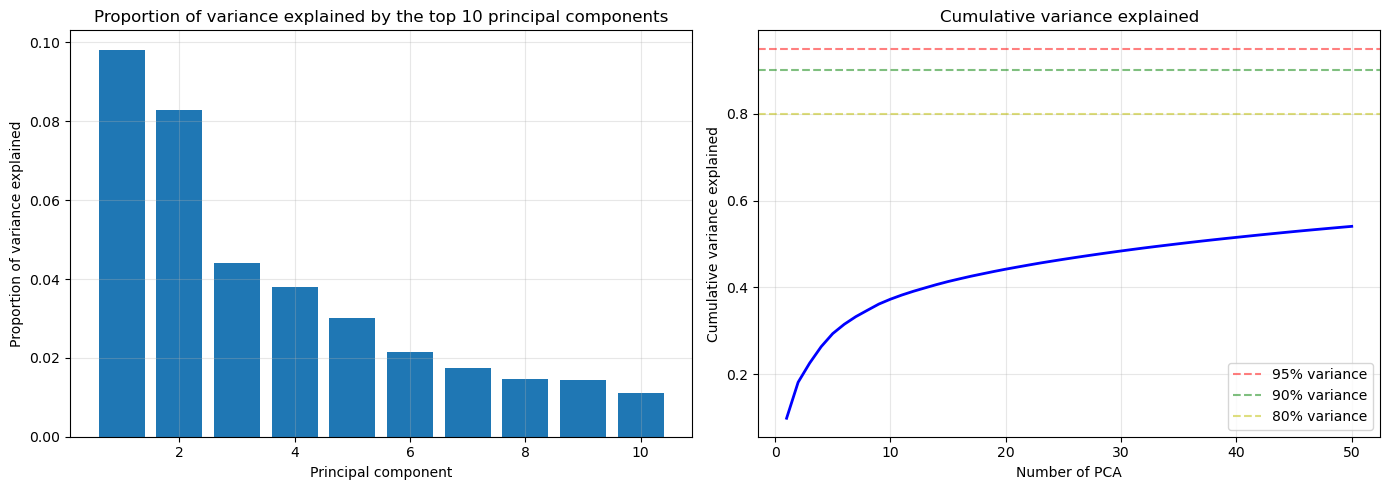

*Figure retained from the original homework run; not regenerated.*


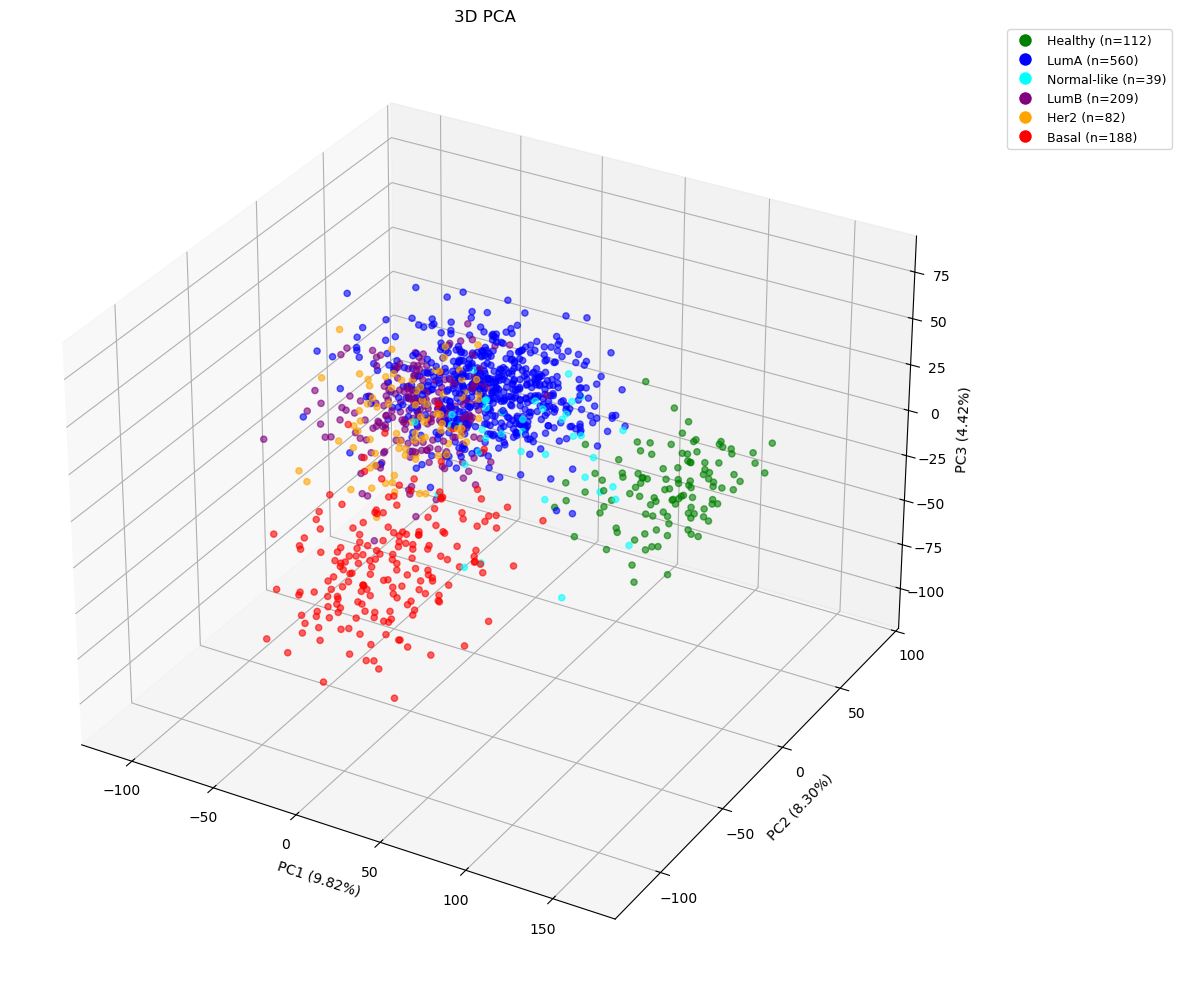

*Figure retained from the original homework run; not regenerated.*


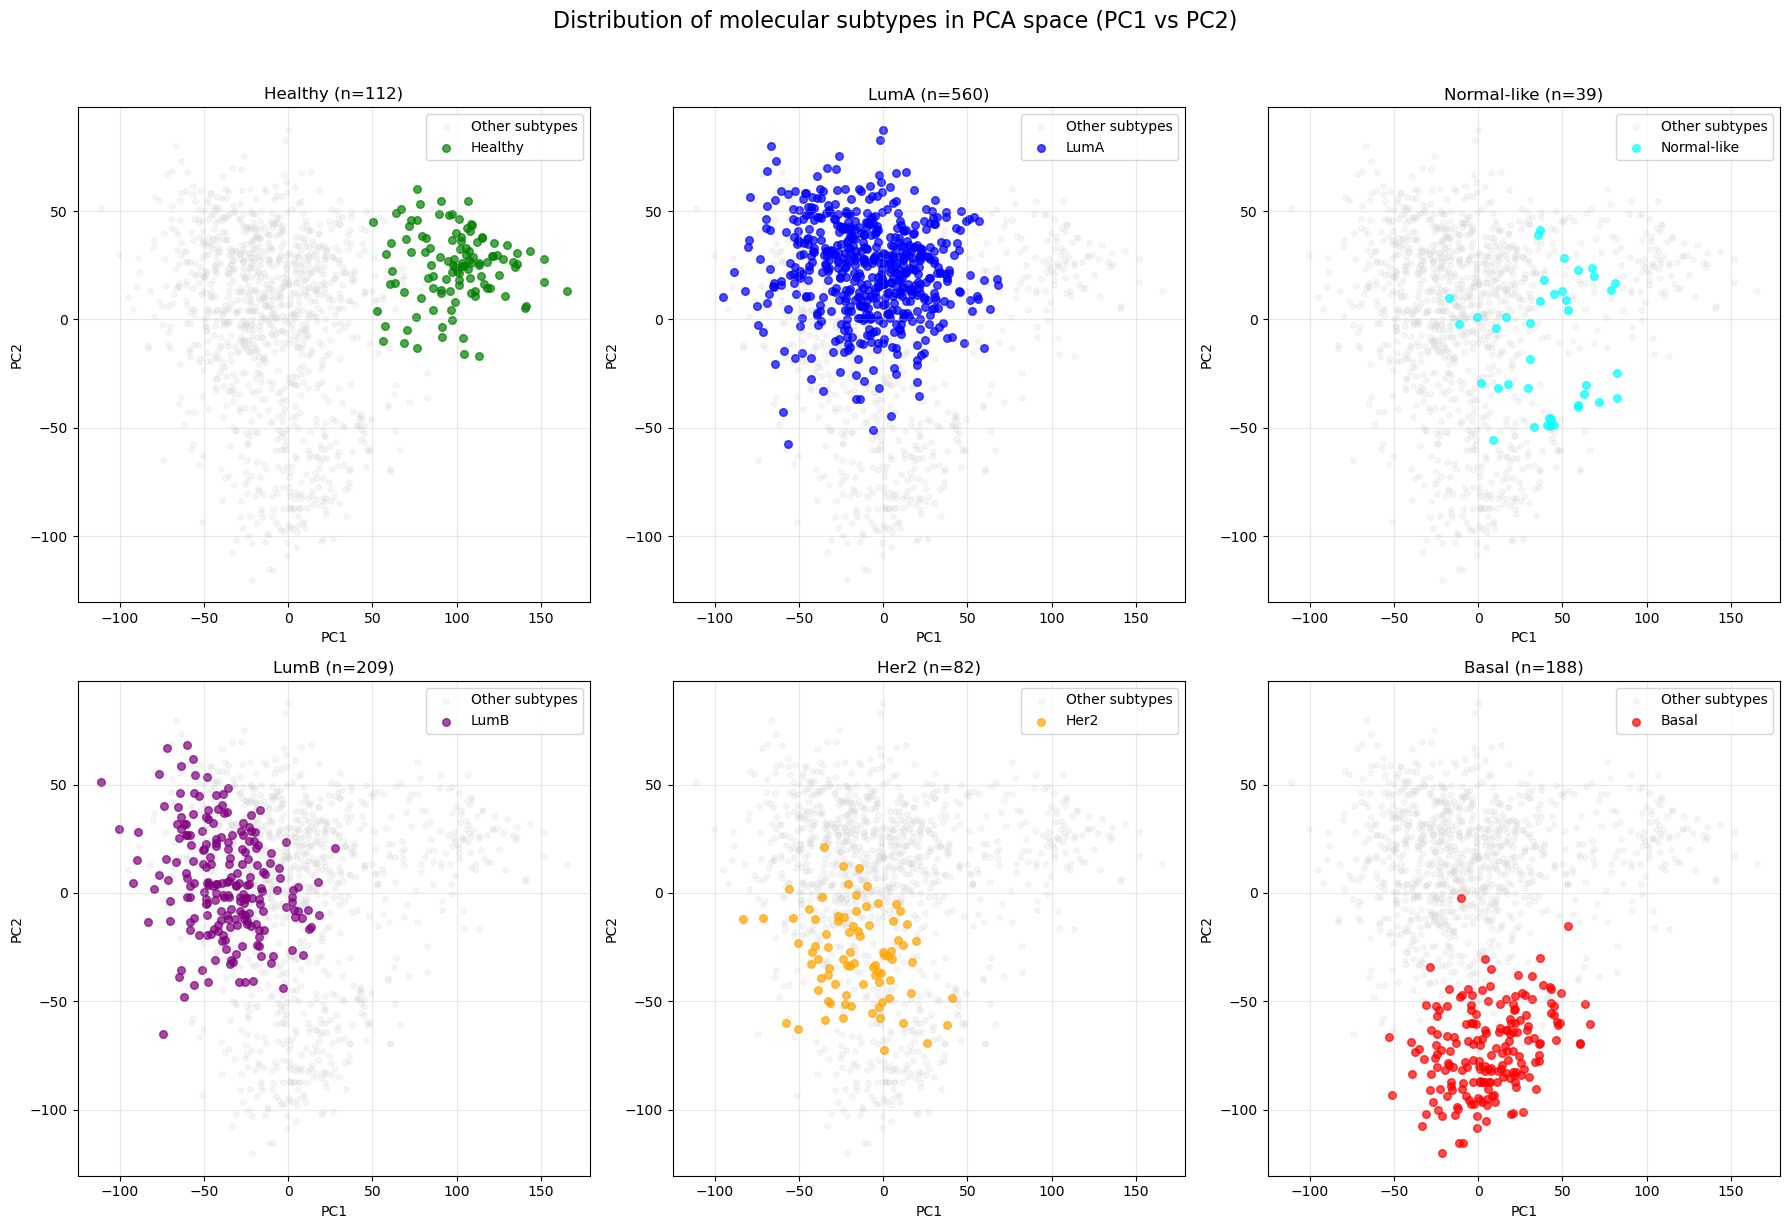

*Figure retained from the original homework run; not regenerated.*


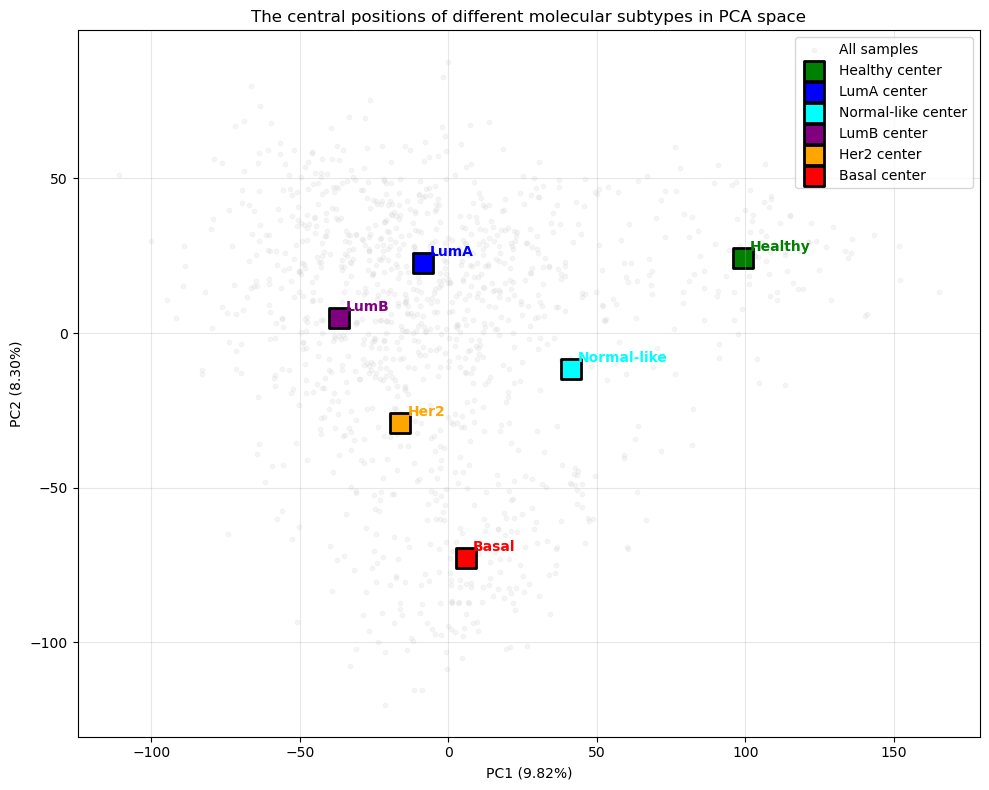

*Figure retained from the original homework run; not regenerated.*


## 3. Train and tune the Luminal A/B random forest

The model uses the first ten PCs for **769 samples**, split into 538 training and 231 test samples. The original grid search evaluated 432 parameter combinations with five-fold MCC scoring. Baseline test MCC was **0.5709**, compared with **0.5693** after tuning; both had accuracy **0.8398**. Tuning did not improve the recorded test MCC.


In [ ]:
print("\n1. Preparing Luminal A and Luminal B data...")

subtype_df = pd.DataFrame({
    'Sample': expression_pca_data.index,
    'Subtype': subtype_labels
})

luminal_samples = subtype_df[subtype_df['Subtype'].isin(['LumA', 'LumB'])]
print(f"Found {len(luminal_samples)} Luminal samples")
print(f"  - Luminal A: {sum(luminal_samples['Subtype'] == 'LumA')}")
print(f"  - Luminal B: {sum(luminal_samples['Subtype'] == 'LumB')}")

if len(luminal_samples) < 20:
    print("Warning: Too few Luminal samples, classifier performance may be affected")
    raise ValueError("Check the input cohort and required clinical columns.")

print("\n2. Creating feature matrix and labels...")

luminal_indices = [
    i for i, sample in enumerate(expression_pca_data.index)
    if sample in luminal_samples['Sample'].values
]

n_components = 10
# The classifier uses PC scores, not individual gene-expression columns.
X_luminal_pca = pca_result[luminal_indices, :n_components]
y_luminal = [subtype_labels[i] for i in luminal_indices]

print(f"Feature matrix shape (top 10 PCs): {X_luminal_pca.shape}")
print(f"Number of labels: {len(y_luminal)}")
print(
    f"Variance explained by top 10 PCs: "
    f"{np.sum(pca.explained_variance_ratio_[:n_components]):.4f} "
    f"({np.sum(pca.explained_variance_ratio_[:n_components]) * 100:.2f}%)"
)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_numeric = le.fit_transform(y_luminal)
print(f"Label encoding: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\n3. Splitting training and test sets...")
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_luminal_pca,
    y_numeric,
    test_size=0.3,
    random_state=42,
    stratify=y_numeric
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training class distribution: LumA={sum(y_train==0)}, LumB={sum(y_train==1)}")
print(f"Test class distribution: LumA={sum(y_test==0)}, LumB={sum(y_test==1)}")

print("\n4. Building baseline Random Forest classifier...")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef

rf_base = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("  Training baseline model...")
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

print("\nBaseline model performance evaluation:")
print("-" * 40)


In [ ]:
cm_base = confusion_matrix(y_test, y_pred_base)
print("Confusion matrix:")
print(cm_base)
print(f"  Predicted:   LumA  LumB")
print(f"  True:")
print(f"  LumA    {cm_base[0,0]:4d}  {cm_base[0,1]:4d}")
print(f"  LumB    {cm_base[1,0]:4d}  {cm_base[1,1]:4d}")

tn, fp, fn, tp = cm_base.ravel()
accuracy_base = (tp + tn) / (tp + tn + fp + fn)
precision_base = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_base = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_base = (
    2 * (precision_base * recall_base) /
    (precision_base + recall_base)
    if (precision_base + recall_base) > 0 else 0
)
mcc_base = matthews_corrcoef(y_test, y_pred_base)

print(f"\nAccuracy: {accuracy_base:.4f}")
print(f"Precision: {precision_base:.4f}")
print(f"Recall: {recall_base:.4f}")
print(f"F1 score: {f1_base:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_base:.4f}")

print("\n5. Hyperparameter tuning using simplified grid search...")
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

total_combinations = (
    len(param_grid['n_estimators']) *
    len(param_grid['max_features']) *
    len(param_grid['max_depth']) *
    len(param_grid['min_samples_split']) *
    len(param_grid['min_samples_leaf'])
)
cv_folds = 5
total_fits = total_combinations * cv_folds

print(f"Number of parameter combinations: {total_combinations}")
print(f"Cross-validation folds: {cv_folds}")
print(f"Total models to train: {total_fits}")
print("Starting grid search...")

rf = RandomForestClassifier(random_state=42, n_jobs=4)

# Select RF parameters using the original five-fold MCC objective.
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=make_scorer(matthews_corrcoef),
    cv=cv_folds,
    n_jobs=4,
    verbose=2
)

start_time = time.time()
print(f"\nStart time: {time.strftime('%H:%M:%S')}")
grid_search.fit(X_train, y_train)
end_time = time.time()

print("\nGrid search completed!")
print(f"End time: {time.strftime('%H:%M:%S')}")
print(f"Total runtime: {end_time - start_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation MCC: {grid_search.best_score_:.4f}")


In [ ]:
print("\n6. Training final model using best parameters...")
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("\nOptimized model performance evaluation:")
print("-" * 40)

cm_best = confusion_matrix(y_test, y_pred_best)
print("Confusion matrix:")
print(cm_best)
print(f"  Predicted:   LumA  LumB")
print(f"  True:")
print(f"  LumA    {cm_best[0,0]:4d}  {cm_best[0,1]:4d}")
print(f"  LumB    {cm_best[1,0]:4d}  {cm_best[1,1]:4d}")

tn_best, fp_best, fn_best, tp_best = cm_best.ravel()
accuracy_best = (tp_best + tn_best) / (tp_best + tn_best + fp_best + fn_best)
precision_best = tp_best / (tp_best + fp_best) if (tp_best + fp_best) > 0 else 0
recall_best = tp_best / (tp_best + fn_best) if (tp_best + fn_best) > 0 else 0
f1_best = (
    2 * (precision_best * recall_best) /
    (precision_best + recall_best)
    if (precision_best + recall_best) > 0 else 0
)
mcc_best = matthews_corrcoef(y_test, y_pred_best)

print(f"\nAccuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1 score: {f1_best:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_best:.4f}")

print("\n7. Visualizing model performance...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ax = axes[0, 0]
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['LumA', 'LumB'],
    yticklabels=['LumA', 'LumB'],
    ax=ax
)
ax.set_title('Baseline Model Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

ax = axes[0, 1]
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['LumA', 'LumB'],
    yticklabels=['LumA', 'LumB'],
    ax=ax
)
ax.set_title('Optimized Model Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

ax = axes[0, 2]
feature_importance = best_rf.feature_importances_
pc_labels = [f'PC{i+1}' for i in range(n_components)]
x_pos = np.arange(len(pc_labels))

ax.bar(x_pos, feature_importance, alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(pc_labels, rotation=45)
ax.set_ylabel('Importance')


In [ ]:
ax.set_title('Feature Importance of Top 10 Principal Components')
ax.set_xlim([-0.5, n_components - 0.5])

ax = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
base_scores = [
    accuracy_base,
    precision_base,
    recall_base,
    f1_base,
    mcc_base
]
best_scores = [
    accuracy_best,
    precision_best,
    recall_best,
    f1_best,
    mcc_best
]

x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width / 2, base_scores, width, label='Baseline Model')
ax.bar(x + width / 2, best_scores, width, label='Optimized Model')

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=4
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

ax.plot(train_sizes, train_mean, 'o-', label='Training Score')
ax.plot(train_sizes, test_mean, 'o-', label='Cross-validation Score')

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
ax.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 2]
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.suptitle(
    'Random Forest Classification Performance (Top 10 PCs)',
    fontsize=16,
    y=1.02
)
plt.tight_layout()
plt.show()


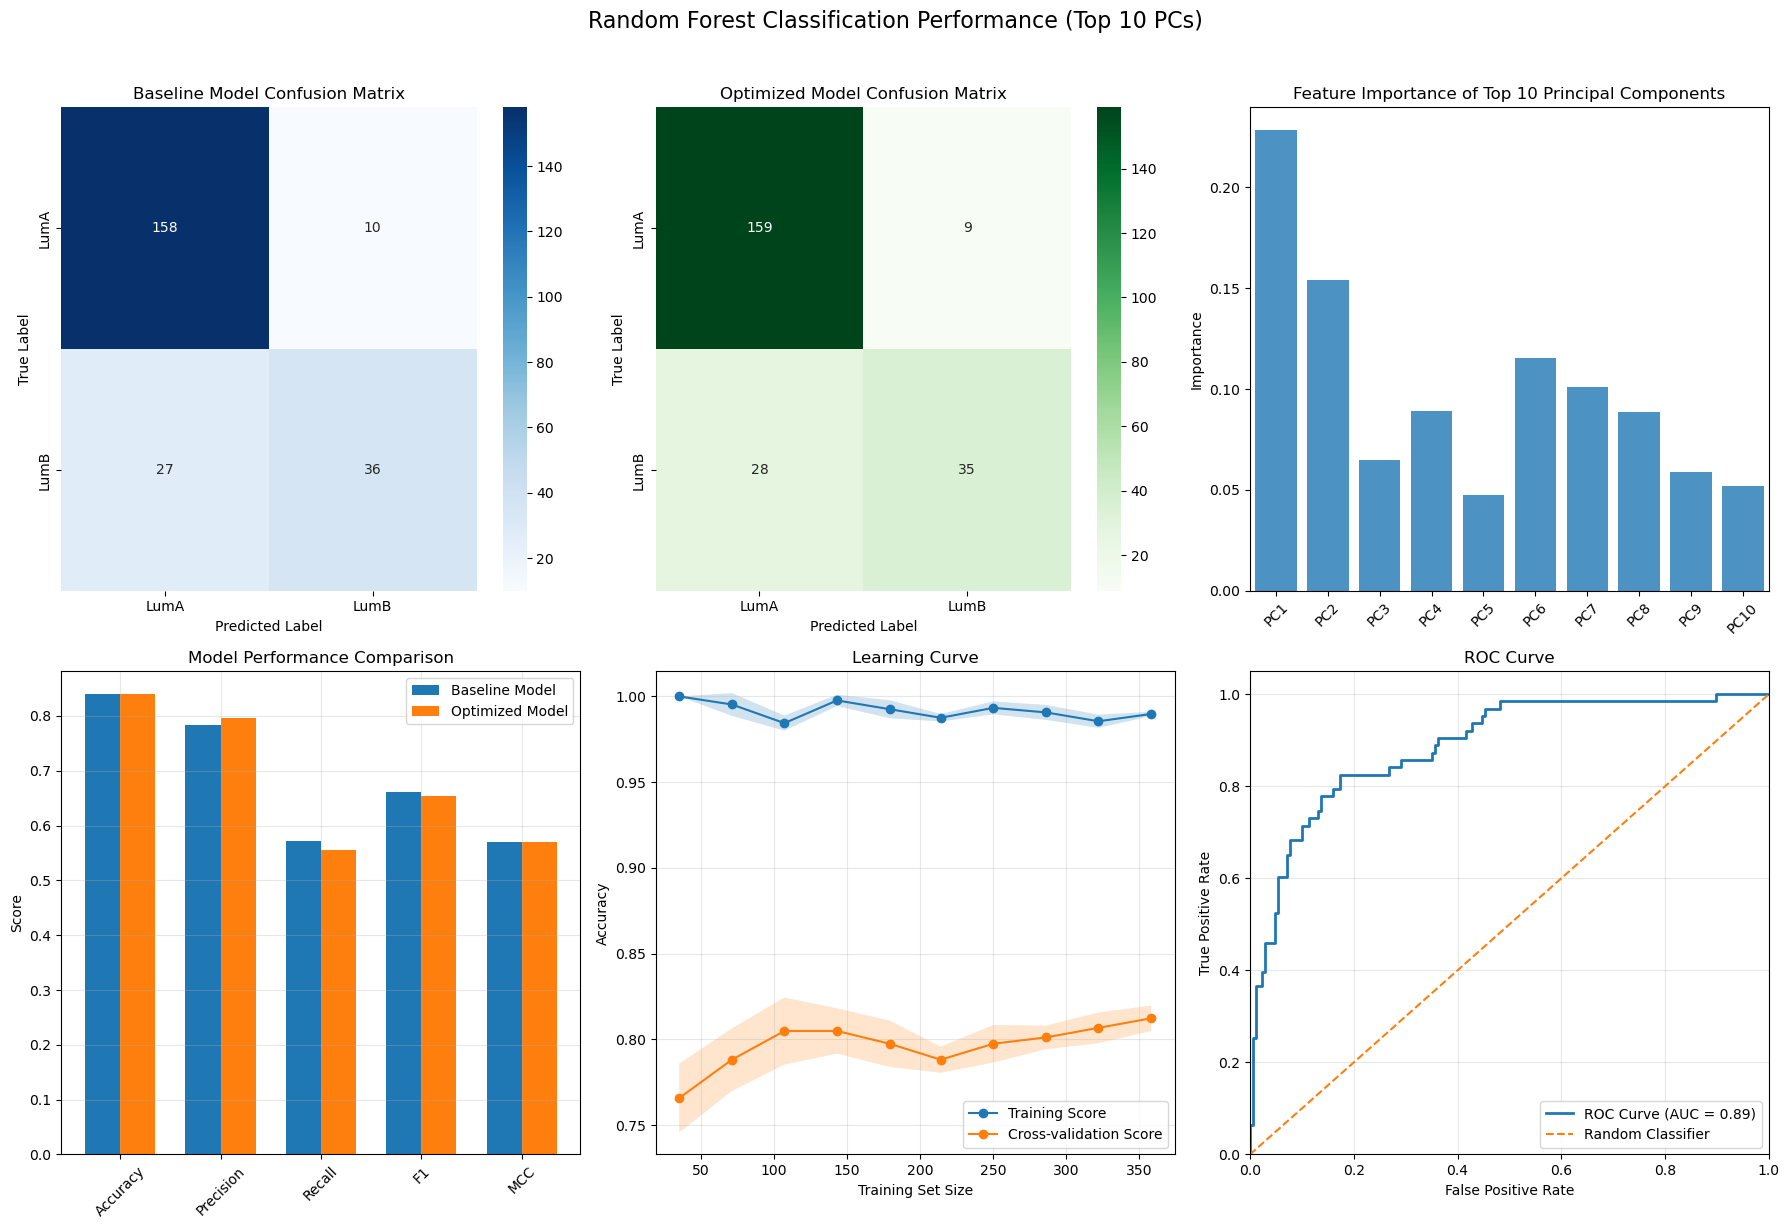

*Figure retained from the original homework run; not regenerated.*


## 4. Select principal components with Boruta and inspect loadings

Boruta accepted **PC1, PC2, PC3, PC4, PC6, PC7 and PC8**. It operated on PC scores, not directly on genes. The original code then listed the 15 largest absolute gene loadings per accepted PC. The selected-PC model had recorded MCC **0.5514**, versus **0.5709** with all ten PCs. Loading-derived candidates are not direction-specific Luminal B markers.


In [ ]:
print("\n" + "="*60)
print("Part Four: Boruta Feature Selector for Identifying Candidate Genes")
print("="*60)

from boruta import BorutaPy

print("\n2. Preparing Boruta input data...")

if not isinstance(X_train, np.ndarray):
    X_train_boruta = X_train.values if hasattr(X_train, 'values') else np.array(X_train)
else:
    X_train_boruta = X_train.copy()

if not isinstance(y_train, np.ndarray):
    y_train_boruta = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
else:
    y_train_boruta = y_train.copy()

print(f"Training data shape: {X_train_boruta.shape}")
print(f"Number of features (top 10 PCs): {X_train_boruta.shape[1]}")
print(f"Number of sampless: {X_train_boruta.shape[0]}")
print(f"Number of LumA samples: {sum(y_train_boruta == 0)}")
print(f"Number of LumB samples: {sum(y_train_boruta == 1)}")

print("\n3. Initializing Boruta feature selector...")

rf_for_boruta = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# Boruta tests the ten principal components used by the classifier.
boruta_selector = BorutaPy(
    estimator=rf_for_boruta,
    n_estimators='auto',
    max_iter=50,
    random_state=42,
    verbose=2
)

print("\n4. Running Boruta feature selection...")
print("Note: This may take some time...")

import time
start_time = time.time()

boruta_selector.fit(X_train_boruta, y_train_boruta)

end_time = time.time()
print(f"Boruta feature selection completed. Time elapsed: {end_time - start_time:.2f} seconds")

print("\n5. Retrieving feature selection results...")

feature_status = boruta_selector.support_
feature_ranking = boruta_selector.ranking_

n_accepted = sum(feature_status)
n_tentative = sum(boruta_selector.support_weak_)
n_rejected = len(feature_status) - n_accepted - n_tentative

print(f"\nFeature selection summary:")
print(f"  Accepted features (important): {n_accepted}")
print(f"  Tentative features: {n_tentative}")
print(f"  Rejected features: {n_rejected}")
print(f"  Total number of features (PCs): {len(feature_status)}")
print(f"  Feature reduction ratio: {(n_rejected / len(feature_status)) * 100:.2f}%")

accepted_indices = np.where(feature_status)[0]
print(f"\nAccepted feature indices: {accepted_indices}")

print(f"\nFeature ranking (1 = most important):")
ranking_counts = np.bincount(feature_ranking)
for rank in range(1, len(ranking_counts)):
    count = ranking_counts[rank]
    if count > 0:
        print(f"  Rank {rank}: {count} features")


In [ ]:
pc_labels = [f'PC{i+1}' for i in range(len(feature_status))]

print(f"\nKey principal components accepted by Boruta:")
for idx in accepted_indices:
    pc_name = f"PC{idx+1}"
    if idx < len(pca.explained_variance_ratio_):
        var_explained = pca.explained_variance_ratio_[idx] * 100
        ranking = feature_ranking[idx]
        print(f"  {pc_name}: Rank {ranking}, Variance explained {var_explained:.2f}%")

print("\n7. Performance comparison: Boruta-selected features vs all features...")

X_train_selected = boruta_selector.transform(X_train_boruta)
X_test_selected = boruta_selector.transform(X_test)

print(f"Training data shape after feature selection: {X_train_selected.shape}")
print(f"Test data shape after feature selection: {X_test_selected.shape}")

rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("  Training model using all features...")
rf_all.fit(X_train_boruta, y_train_boruta)

print("  Training model using Boruta-selected features...")
rf_selected.fit(X_train_selected, y_train_boruta)

y_pred_all = rf_all.predict(X_test)
y_pred_selected = rf_selected.predict(X_test_selected)

mcc_all = matthews_corrcoef(y_test, y_pred_all)
mcc_selected = matthews_corrcoef(y_test, y_pred_selected)
accuracy_all = (y_pred_all == y_test).mean()
accuracy_selected = (y_pred_selected == y_test).mean()

print(f"\nPerformance comparison results:")
print(f"  All-features model MCC: {mcc_all:.4f}")
print(f"  Boruta-selected model MCC: {mcc_selected:.4f}")
print(f"  Performance change: {(mcc_selected - mcc_all):+.4f}")
print(f"  All-features model accuracy: {accuracy_all:.4f}")
print(f"  Boruta-selected model accuracy: {accuracy_selected:.4f}")

if mcc_selected > mcc_all:
    print("  Boruta feature selection improved model performance")
elif abs(mcc_selected - mcc_all) < 0.05:
    print("  Boruta feature selection had little impact on performance")
else:
    print("  Boruta feature selection reduced model performance")

print("\n8. Mapping key principal components back to candidate genes...")

try:
    gene_names = high_var_genes.index.tolist()
    print(f"Successfully retrieved {len(gene_names)} gene names")

    all_key_genes = []
    key_genes_with_details = []

    print(f"\nList of candidate genes:")
    print("=" * 80)

    for pc_idx in accepted_indices:
        if pc_idx < pca.components_.shape[0]:
            pc_loading = pca.components_[pc_idx]

            sorted_indices = np.argsort(np.abs(pc_loading))[::-1]

            top_n = min(15, len(gene_names))
            top_indices = sorted_indices[:top_n]

            print(f"\nTop {top_n} candidate genes for principal component PC{pc_idx+1}:")
            print("-" * 60)

            for i, idx in enumerate(top_indices):
                gene_name = gene_names[idx] if idx < len(gene_names) else f"Gene_{idx}"
                loading_value = pc_loading[idx]
                abs_loading = abs(loading_value)

                direction = "Positive" if loading_value > 0 else "Negative"
                print(
                    f"  {i+1:2d}. {gene_name:20s} "
                    f"Loading: {loading_value:.4f} "
                    f"({direction}, Absolute: {abs_loading:.4f})"
                )

                all_key_genes.append(gene_name)
                key_genes_with_details.append({
                    'Gene': gene_name,
                    'Principal_Component': f'PC{pc_idx+1}',
                    'Loading': loading_value,
                    'Absolute_Loading': abs_loading,
                    'Direction': direction,
                    'Rank': i + 1
                })
        else:
            print(f"\nWarning: Principal component index {pc_idx} is out of range")

    if key_genes_with_details:
        key_genes_df = pd.DataFrame(key_genes_with_details)
        key_genes_df = key_genes_df.sort_values(
            ['Principal_Component', 'Absolute_Loading'],
            ascending=[True, False]
        )

        print(f"\nCandidate gene statistics:")
        print(f"  Total unique candidate genes identified: {len(set(all_key_genes))}")
        print(f"  Total gene–PC associations: {len(key_genes_with_details)}")

        RESULT_DIR.mkdir(parents=True, exist_ok=True)

        key_genes_df.to_csv(
            RESULT_DIR / 'key_genes_details.csv',
            index=False
        )
        print("Candidate gene details saved: boruta_results_pca/key_genes_details.csv")

        unique_genes_df = pd.DataFrame({
            'Key_Gene': sorted(list(set(all_key_genes)))
        })
        unique_genes_df.to_csv(
            RESULT_DIR / 'unique_key_genes.csv',
            index=False
        )
        print("Unique candidate gene list saved: boruta_results_pca/unique_key_genes.csv")

        with open(RESULT_DIR / 'unique_key_genes.txt', 'w') as f:
            for gene in sorted(list(set(all_key_genes))):
                f.write(f"{gene}\n")
        print("Candidate gene text file saved: boruta_results_pca/unique_key_genes.txt")

        print("\nTop 20 most important candidate genes (by absolute loading):")
        print("-" * 80)

        top_genes = key_genes_df.sort_values(
            'Absolute_Loading',
            ascending=False
        ).head(20)

        for _, row in top_genes.iterrows():
            print(
                f"  {row['Rank']:2d}. {row['Gene']:20s} "
                f"({row['Principal_Component']}) "
                f"Loading: {row['Loading']:.4f} "
                f"({row['Direction']})"
            )

except Exception as e:
    print(f"Error occurred while retrieving gene names or mapping PCs: {e}")
    print(f"Error message: {str(e)}")


## 5. Exploratory pathway follow-up

The original submission included the two enrichment screenshots below and discussed
KEGG pathways and GO Biological Processes. They are retained as a record of that
follow-up. No Enrichr query, background list, dated library specification or complete
results table is stored in the notebook, so this section cannot be reproduced from
the supplied code alone. PC loading signs do not by themselves identify genes
upregulated in Luminal B. No pathway activation claim is made here.


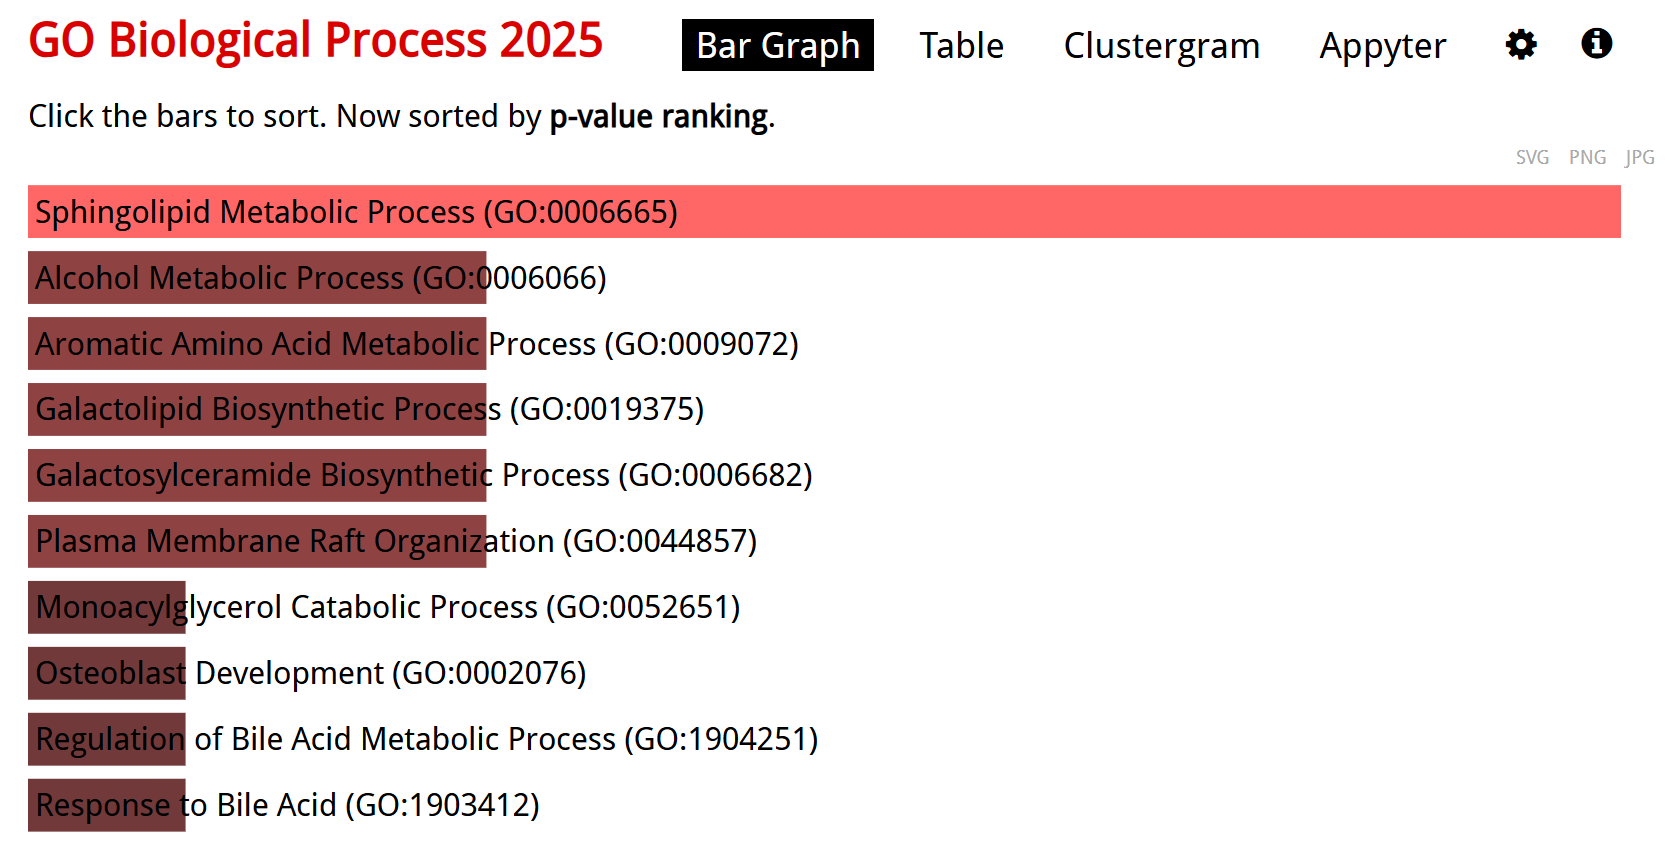

*Screenshot retained from the original homework.*


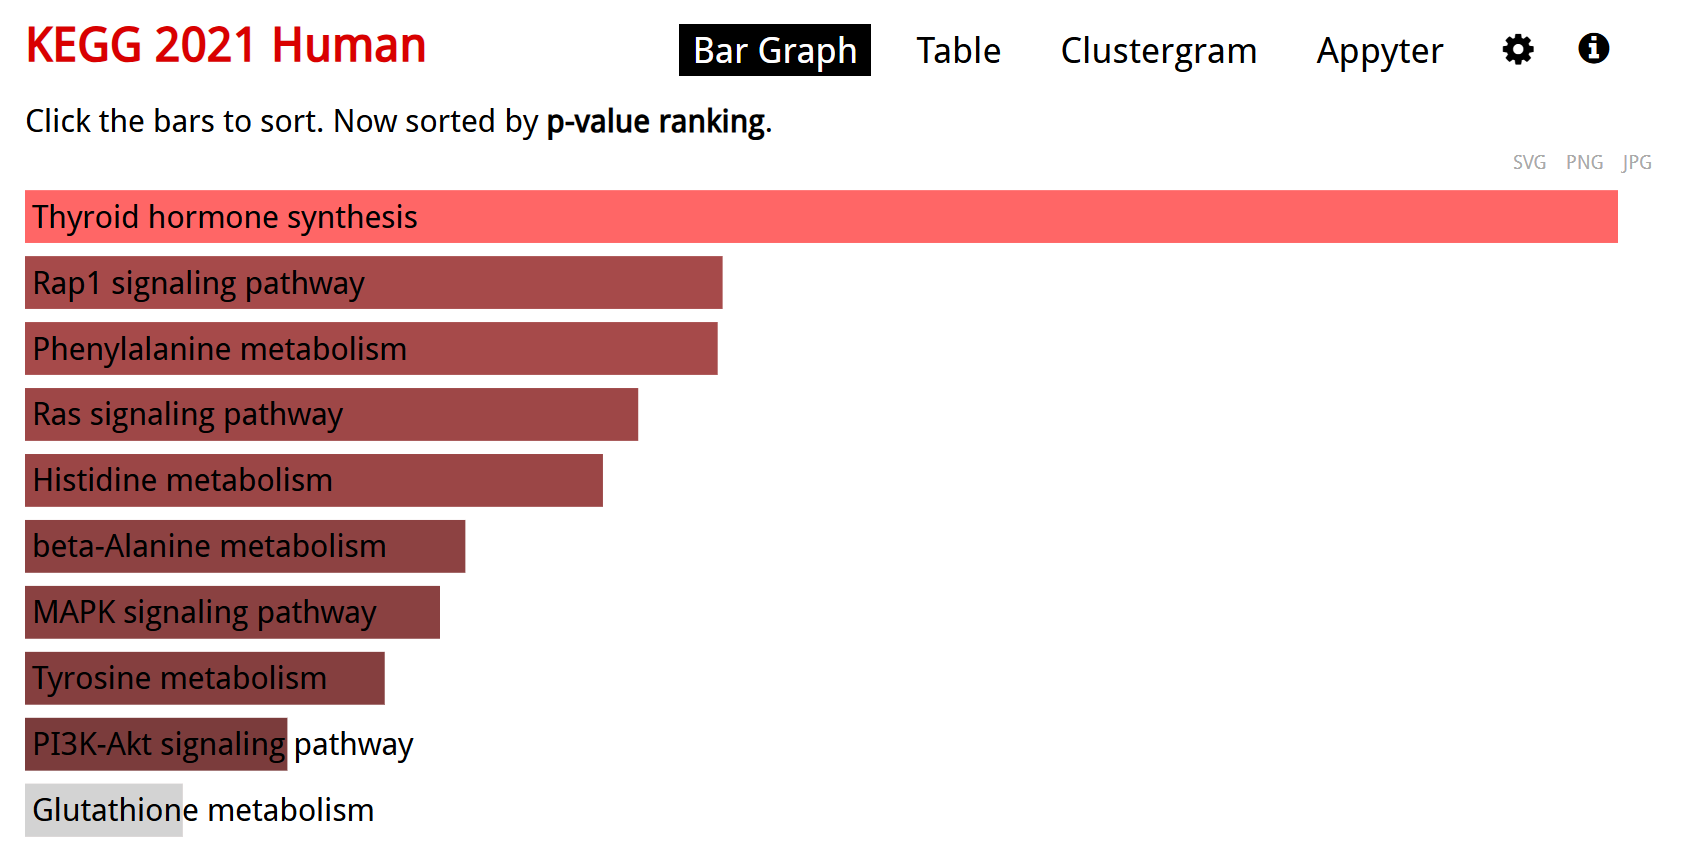

*Screenshot retained from the original homework.*


## 6. Interpretation and limitations

The recorded random-forest comparison shows useful separation of the supplied
Luminal A/B labels, with most errors involving LumB predictions. Neither tuning nor
Boruta improved the recorded MCC. PC importance and gene loadings describe the
representation; they do not independently validate biomarkers.

The original preprocessing uses the full cohort before splitting, and cross-validation
reuses those fitted PCs. PAM50 labels are themselves expression-derived, so this
task is label recovery rather than prediction of an independent clinical outcome.
A future validation would fit preprocessing within training folds, group samples
by patient and evaluate in an independent cohort. The present scores remain the
original coursework results; no revised score is claimed.

[Original saved text output](../results/luminal_subtype/original_stdout.txt) ·
[Editorial notes](../docs/editorial_notes.md)
